Data shape: (150, 2)
Total points: 150
True clusters: 3 (we planted them!)
Note: K-Means does NOT know this!
RUNNING K-MEANS FROM SCRATCH

Initial centroids (picked from data):
  Centroid 1: (-0.07, 1.00)
  Centroid 2: (-0.46, 1.06)
  Centroid 3: (4.58, -0.42)

Iteration 1:
  Points that changed: checking...
  Centroid movement: 7.159258

Iteration 2:
  Points that changed: checking...
  Points that switched clusters: 35
  Centroid movement: 5.065094

Iteration 3:
  Points that changed: checking...
  Points that switched clusters: 9
  Centroid movement: 1.290240

Iteration 4:
  Points that changed: checking...
  Points that switched clusters: 0
  Centroid movement: 0.000000

✓ Converged at iteration 4!
  No more movement. Done!

Final centroids:
  Cluster 1: (3.04, 5.08)
  Cluster 2: (-0.14, -0.07)
  Cluster 3: (5.88, 0.25)

Points per cluster:
  Cluster 1: 48 points
  Cluster 2: 50 points
  Cluster 3: 52 points


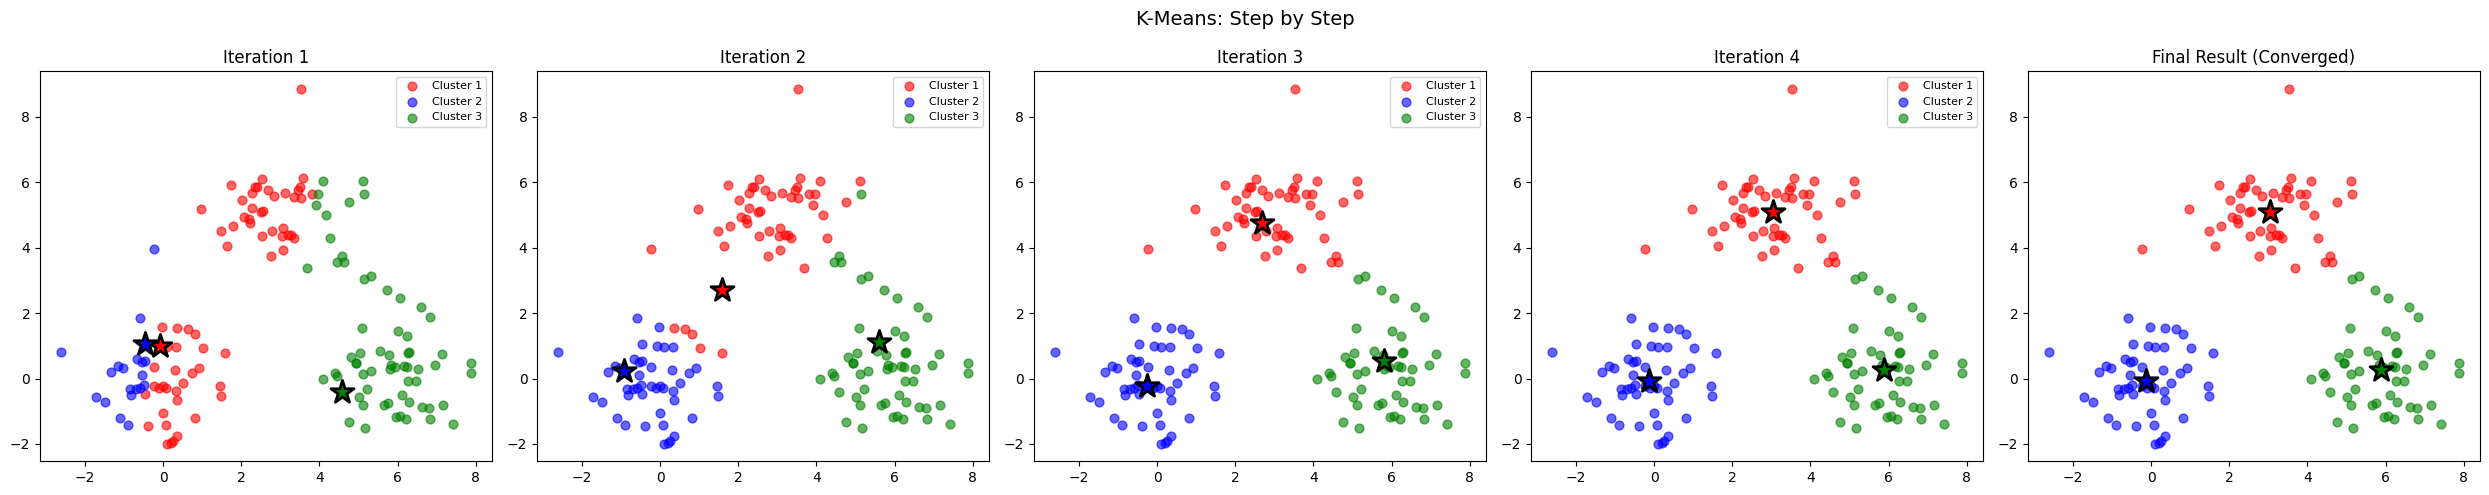

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# WHAT IS K-MEANS CLUSTERING?
# K-Means is an UNSUPERVISED algorithm — it receives no labels, only raw data.
# Its job is to discover natural groupings (clusters) on its own.
#
# The algorithm works in two repeating steps:
#   ASSIGN: each data point is assigned to the nearest cluster center (centroid).
#   UPDATE: each centroid moves to the average position of its assigned points.
# These two steps repeat until the centroids stop moving (convergence).
#
# "K" is the number of clusters you want — you must choose this in advance.
# That's one of the main limitations: K-Means doesn't figure out K for you.

# ============================================
# STEP 1: GENERATE CLEAN DATA
# ============================================
# We manually create 3 well-separated blobs so we can verify that K-Means
# discovers exactly what we planted. In real life you won't know the answer.

np.random.seed(42)  # fix randomness so results are reproducible

# np.random.randn(50, 2) draws 50 points from a standard normal distribution.
# Adding a constant vector shifts the whole cloud to a different location.
cluster1 = np.random.randn(50, 2) + np.array([0, 0])   # centered at origin
cluster2 = np.random.randn(50, 2) + np.array([6, 0])   # shifted 6 units right
cluster3 = np.random.randn(50, 2) + np.array([3, 5])   # shifted up and right

# Stack all 150 points into one array. K-Means sees this as one unlabeled blob.
X = np.vstack([cluster1, cluster2, cluster3])

print(f"Data shape: {X.shape}")
print(f"Total points: {len(X)}")
print(f"True clusters: 3 (we planted them!)")
print(f"Note: K-Means does NOT know this!")

# ============================================
# STEP 2: K-MEANS FROM SCRATCH
# ============================================

class KMeansScratch:
    """
    K-Means built from scratch.
    Every line is something you understand!
    """
    
    def __init__(self, K, max_iterations=100):
        self.K = K                           # number of clusters to find
        self.max_iterations = max_iterations # safety cap so we don't loop forever
        self.centroids = None                # will hold the K centroid positions
        self.labels = None                   # will hold each point's cluster assignment
        self.history = []                    # snapshot of every iteration for visualization
    
    def fit(self, X):
        n_points = len(X)
        
        # ─────────────────────────────────
        # INITIALIZATION
        # Pick K random data points as starting centroids.
        # We choose actual data points (not random locations) so centroids
        # start somewhere reasonable. This is the "random" init strategy.
        # (K-Means++ is smarter — sklearn uses that by default.)
        # ─────────────────────────────────
        
        random_indices = np.random.choice(n_points, self.K, replace=False)
        self.centroids = X[random_indices].copy()  # .copy() so we don't modify X
        
        print(f"\nInitial centroids (picked from data):")
        for i, c in enumerate(self.centroids):
            print(f"  Centroid {i+1}: ({c[0]:.2f}, {c[1]:.2f})")
        
        # ─────────────────────────────────
        # MAIN LOOP: Assign + Update
        # Repeat until convergence or until we hit max_iterations.
        # ─────────────────────────────────
        
        for iteration in range(self.max_iterations):
            
            # ASSIGN STEP: give each point a cluster label based on proximity.
            labels = self._assign_clusters(X)
            
            # Save a snapshot so we can animate the learning process later.
            self.history.append({
                'centroids': self.centroids.copy(),
                'labels': labels.copy(),
                'iteration': iteration
            })
            
            # UPDATE STEP: move each centroid to the mean of its cluster.
            new_centroids = self._update_centroids(X, labels)
            
            # CONVERGENCE CHECK: if centroids barely moved, we're done.
            # np.abs gives per-element absolute difference; np.sum adds them all up.
            movement = np.sum(np.abs(new_centroids - self.centroids))
            
            print(f"\nIteration {iteration + 1}:")
            print(f"  Points that changed: checking...")
            
            if iteration > 0:
                old_labels = self.history[-2]['labels']
                changed = np.sum(labels != old_labels)
                print(f"  Points that switched clusters: {changed}")
            
            print(f"  Centroid movement: {movement:.6f}")
            
            self.centroids = new_centroids
            self.labels = labels
            
            # 1e-6 is effectively zero — if total movement is this small,
            # further iterations won't change anything meaningful.
            if movement < 1e-6:
                print(f"\n✓ Converged at iteration {iteration + 1}!")
                print(f"  No more movement. Done!")
                break
        
        return self
    
    def _assign_clusters(self, X):
        """
        For each point, find nearest centroid.
        
        This is the 'assign' step!
        Distance formula: sqrt( (x1-x2)² + (y1-y2)² )  (Euclidean distance)
        """
        
        labels = np.zeros(len(X), dtype=int)
        
        for i, point in enumerate(X):
            
            # Compute distance from this point to every centroid.
            distances = []
            for centroid in self.centroids:
                # Euclidean distance: square root of sum of squared differences.
                dist = np.sqrt(np.sum((point - centroid) ** 2))
                distances.append(dist)
            
            # np.argmin returns the INDEX of the smallest distance.
            # That index is the cluster number we assign this point to.
            labels[i] = np.argmin(distances)
        
        return labels
    
    def _update_centroids(self, X, labels):
        """
        Move each centroid to center (mean) of its cluster.
        
        This is the 'update' step!
        New centroid = average position of all points assigned to that cluster.
        """
        
        new_centroids = np.zeros((self.K, X.shape[1]))
        
        for k in range(self.K):
            
            # Boolean indexing: select only the rows assigned to cluster k.
            cluster_points = X[labels == k]
            
            if len(cluster_points) > 0:
                # axis=0 means average across rows (one mean per column/feature).
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                # Empty clusters are rare but possible with unlucky initialization.
                # Keeping the old centroid avoids a crash.
                new_centroids[k] = self.centroids[k]
        
        return new_centroids
    
    def predict(self, X):
        """Assign new (unseen) points to the nearest centroid."""
        return self._assign_clusters(X)


# ============================================
# STEP 3: RUN IT!
# ============================================

print("=" * 60)
print("RUNNING K-MEANS FROM SCRATCH")
print("=" * 60)

kmeans_scratch = KMeansScratch(K=3)
kmeans_scratch.fit(X)

print(f"\nFinal centroids:")
for i, c in enumerate(kmeans_scratch.centroids):
    print(f"  Cluster {i+1}: ({c[0]:.2f}, {c[1]:.2f})")

print(f"\nPoints per cluster:")
for k in range(3):
    count = np.sum(kmeans_scratch.labels == k)
    print(f"  Cluster {k+1}: {count} points")

# ============================================
# STEP 4: VISUALIZE THE JOURNEY
# ============================================
# Each subplot shows one iteration of the algorithm:
#   Colored dots = data points, colored by their current cluster assignment.
#   Stars (★)    = centroid positions for that iteration.
# Watch how points switch colors and stars march toward cluster centers.

colors = ['red', 'blue', 'green']
n_steps = min(4, len(kmeans_scratch.history))  # show at most 4 iterations

fig, axes = plt.subplots(1, n_steps + 1, figsize=(5 * (n_steps + 1), 5))

for step in range(n_steps):
    state = kmeans_scratch.history[step]
    ax = axes[step]
    
    for k in range(3):
        mask = state['labels'] == k
        ax.scatter(X[mask, 0], X[mask, 1], 
                  c=colors[k], alpha=0.6, s=40,
                  label=f'Cluster {k+1}')
    
    for k, centroid in enumerate(state['centroids']):
        # s=300 makes the star large and easy to see.
        # zorder=5 draws the star on top of the scatter points.
        ax.scatter(*centroid, c=colors[k], s=300, 
                  marker='*', edgecolors='black', linewidth=2,
                  zorder=5)
    
    ax.set_title(f"Iteration {step + 1}")
    ax.legend(fontsize=8)

# The final subplot shows the converged result.
ax = axes[-1]
for k in range(3):
    mask = kmeans_scratch.labels == k
    ax.scatter(X[mask, 0], X[mask, 1],
              c=colors[k], alpha=0.6, s=40)

for k, centroid in enumerate(kmeans_scratch.centroids):
    ax.scatter(*centroid, c=colors[k], s=300,
              marker='*', edgecolors='black', linewidth=2, zorder=5)

ax.set_title("Final Result (Converged)")

plt.suptitle("K-Means: Step by Step", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("SKLEARN K-MEANS")
print("=" * 60)

# WHY SCALE FOR K-MEANS?
# K-Means assigns points to clusters based on Euclidean distance.
# If one feature has range 0–10,000 and another has range 0–1,
# the large-range feature dominates every distance calculation and
# the small-range feature is effectively ignored.
# StandardScaler brings all features to mean=0, std=1 so each
# feature contributes equally to the distance computation.
# Rule of thumb: any distance-based algorithm (K-Means, SVM, KNN)
# needs scaling; tree-based algorithms (RF, XGBoost) do not.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit on X (only one dataset here, no separate test set)

# sklearn's KMeans — production-quality, much faster than our scratch version.
kmeans = KMeans(
    n_clusters=3,        # K = how many groups to find
    init='k-means++',    # smarter initialization: spreads starting centroids apart
                         # so we avoid unlucky random starts that lead to bad clusters
    n_init=10,           # run the full algorithm 10 times with different random starts
                         # and keep the best result (lowest inertia) — reduces bad luck
    max_iter=300,        # maximum iterations per run (300 is rarely reached)
    random_state=42      # makes results reproducible
)

kmeans.fit(X_scaled)

# n_iter_: how many iterations the BEST run actually needed before converging.
print(f"Converged in: {kmeans.n_iter_} iterations")

# cluster_centers_: the final centroid coordinates in SCALED space.
# They look small because the scaled data has mean~0 and std~1.
print(f"\nCluster centers (scaled):")
for i, c in enumerate(kmeans.cluster_centers_):
    print(f"  Cluster {i+1}: ({c[0]:.3f}, {c[1]:.3f})")

print(f"\nPoints per cluster:")
labels, counts = np.unique(kmeans.labels_, return_counts=True)
for label, count in zip(labels, counts):
    print(f"  Cluster {label+1}: {count} points")

# INERTIA = the sum of squared distances from each point to its centroid.
# Think of it as "how tight are the clusters?"
# Lower inertia = points are closer to their centroids = tighter, better clusters.
# Inertia always decreases as K increases, so it can't be used alone to pick K
# (K = n_points would give inertia = 0, but that's useless). Use the elbow method instead.
print(f"\nInertia (total distance²): {kmeans.inertia_:.2f}")
print("  Lower inertia = tighter clusters ✓")

SKLEARN K-MEANS
Converged in: 4 iterations

Cluster centers (scaled):
  Cluster 1: (0.062, 1.301)
  Cluster 2: (-1.171, -0.692)
  Cluster 3: (1.110, -0.609)

Points per cluster:
  Cluster 1: 50 points
  Cluster 2: 50 points
  Cluster 3: 50 points

Inertia (total distance²): 42.55
  Lower inertia = tighter clusters ✓


CHOOSING K: THE ELBOW METHOD
K=1: Inertia=300.00
K=2: Inertia=160.09
K=3: Inertia=42.55
K=4: Inertia=35.58
K=5: Inertia=30.74
K=6: Inertia=26.76
K=7: Inertia=22.22
K=8: Inertia=19.64
K=9: Inertia=16.88
K=10: Inertia=15.50


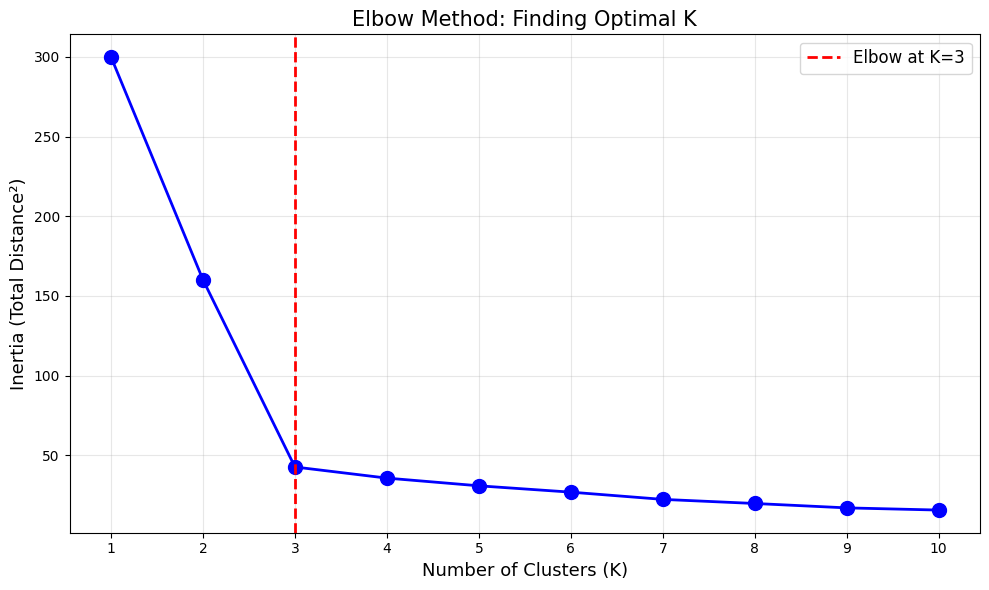


INTERPRETATION:
  K=1→2: Big drop in inertia (adds real value)
  K=2→3: Big drop in inertia (adds real value)
  K=3→4: Small drop (diminishing returns)
  K=4+:  Tiny drops (not worth the complexity)
  ✓ Elbow at K=3: That's our answer!


In [7]:
print("=" * 60)
print("CHOOSING K: THE ELBOW METHOD")
print("=" * 60)

# HOW DO YOU PICK K?
# This is one of the hardest parts of K-Means. The algorithm won't tell you —
# you have to choose K before training.
#
# THE ELBOW METHOD:
# Train K-Means for K = 1, 2, 3, ..., N and record the inertia each time.
# Plot inertia vs K. The curve drops steeply at first (adding more clusters
# captures real structure), then flattens out (extra clusters just split
# existing groups in half — diminishing returns).
#
# The "elbow" is the K where the curve bends — the last K that gives a big
# improvement. That's your best guess for the true number of clusters.
# It's a heuristic, not a guarantee, but it works well in practice.

inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++',
                    n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}")

# ── ELBOW CURVE ───────────────────────────────────────────────
# Each point on the line is the inertia for that value of K.
# Look for where the line "bends" — that's the elbow.
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia (Total Distance²)', fontsize=13)
plt.title('Elbow Method: Finding Optimal K', fontsize=15)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

# The red dashed line marks where we expect the elbow based on the data we created.
plt.axvline(x=3, color='red', linestyle='--', linewidth=2,
            label='Elbow at K=3')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("  K=1→2: Big drop in inertia (adds real value)")
print("  K=2→3: Big drop in inertia (adds real value)")
print("  K=3→4: Small drop (diminishing returns)")
print("  K=4+:  Tiny drops (not worth the complexity)")
print("  ✓ Elbow at K=3: That's our answer!")

REAL WORLD: CUSTOMER SEGMENTATION
Customer data: (300, 3)
Features: Age, Income ($k), Purchases/month
Labels: NONE (unsupervised!)


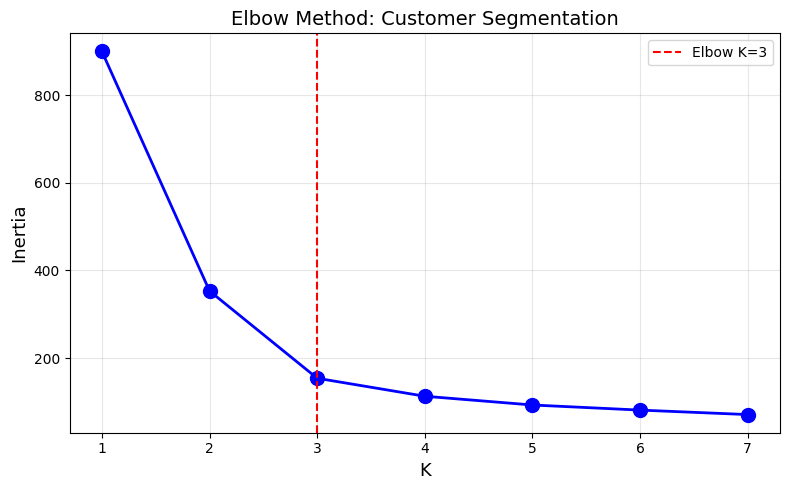


DISCOVERED CUSTOMER SEGMENTS

Segment 1 (100 customers):
  Average Age: 65.1 years
  Average Income: $55k
  Average Purchases/Month: 5.3
  Business Label: 'Senior Moderate Buyers'

Segment 2 (100 customers):
  Average Age: 24.7 years
  Average Income: $30k
  Average Purchases/Month: 8.1
  Business Label: 'Young Budget Shoppers'

Segment 3 (100 customers):
  Average Age: 45.5 years
  Average Income: $89k
  Average Purchases/Month: 2.9
  Business Label: 'Premium Professionals'


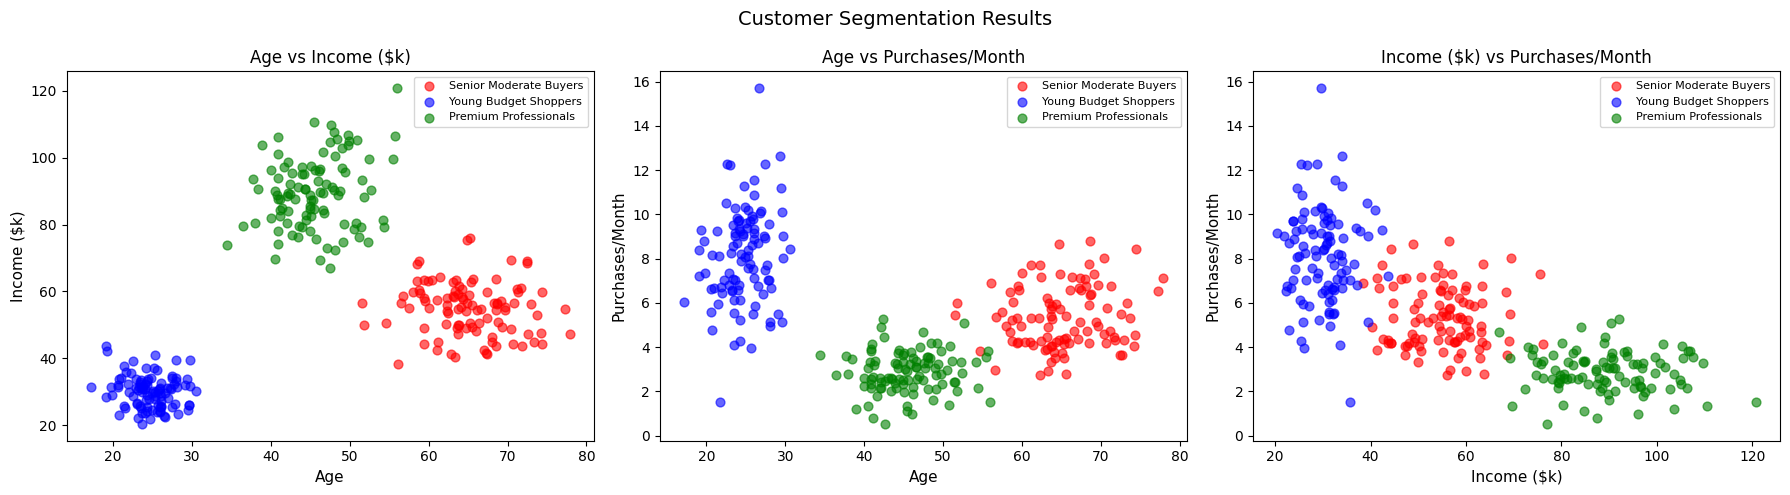


✓ Customer segmentation complete!

Business Actions:
  Young Budget Shoppers → Discount alerts, fast fashion
  Premium Professionals → Exclusive products, quality focus
  Senior Moderate Buyers → Loyalty programs, classic lines


In [8]:
print("=" * 60)
print("REAL WORLD: CUSTOMER SEGMENTATION")
print("=" * 60)

# WHY CUSTOMER SEGMENTATION?
# Businesses want to tailor their marketing to different types of customers.
# But they don't hand-label every customer as "budget" or "premium" upfront.
# K-Means can discover these groups automatically from behavioral data alone.
# This is unsupervised learning's killer use case in industry.

np.random.seed(42)
n_customers = 300

# Simulate three distinct customer archetypes with realistic characteristics.
# np.random.normal(mean, std, count) draws from a normal distribution.
# np.column_stack builds a 2D array where each column is one feature.

# Segment A: young, lower income, shops frequently (budget-conscious)
young_budget = np.column_stack([
    np.random.normal(25, 3, 100),   # Age: 25 ± 3 years
    np.random.normal(30, 5, 100),   # Income: ~$30k/year
    np.random.normal(8, 2, 100),    # Purchases/month: ~8
])

# Segment B: middle-aged, high income, shops selectively (quality-focused)
middle_premium = np.column_stack([
    np.random.normal(45, 5, 100),   # Age: 45 ± 5 years
    np.random.normal(90, 10, 100),  # Income: ~$90k/year
    np.random.normal(3, 1, 100),    # Purchases/month: ~3 (fewer but higher value)
])

# Segment C: older, moderate income, shops regularly (loyalty-driven)
senior_moderate = np.column_stack([
    np.random.normal(65, 5, 100),   # Age: 65 ± 5 years
    np.random.normal(55, 8, 100),   # Income: ~$55k/year
    np.random.normal(5, 1.5, 100),  # Purchases/month: ~5
])

# Combine into one unlabeled dataset — just like a real CRM export.
customers = np.vstack([young_budget, middle_premium, senior_moderate])

print(f"Customer data: {customers.shape}")
print(f"Features: Age, Income ($k), Purchases/month")
print(f"Labels: NONE (unsupervised!)")

# SCALE before clustering. Age, income, and purchase counts are on very
# different scales ($90k vs 8 purchases). Without scaling, income would
# dominate the distance and age/purchases would be nearly irrelevant.
scaler = StandardScaler()
customers_scaled = scaler.fit_transform(customers)

# ── ELBOW METHOD ──────────────────────────────────────────────
# Find the right K before committing to a final model.
inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    km.fit(customers_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('K', fontsize=13)
plt.ylabel('Inertia', fontsize=13)
plt.title('Elbow Method: Customer Segmentation', fontsize=14)
plt.axvline(x=3, color='red', linestyle='--', label='Elbow K=3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── FINAL MODEL ───────────────────────────────────────────────
# Train with K=3 now that the elbow confirmed it.
kmeans_final = KMeans(n_clusters=3, init='k-means++',
                      n_init=10, random_state=42)
kmeans_final.fit(customers_scaled)

# ── SEGMENT ANALYSIS ──────────────────────────────────────────
# The cluster labels (0, 1, 2) are arbitrary integers — K-Means has no idea
# what they mean. We have to look at the average feature values per cluster
# and interpret them ourselves. That's where domain knowledge comes in.

print("\n" + "=" * 60)
print("DISCOVERED CUSTOMER SEGMENTS")
print("=" * 60)

segment_names = []
for k in range(3):
    # Boolean mask selects only the rows assigned to cluster k.
    mask = kmeans_final.labels_ == k
    # Use ORIGINAL (unscaled) customer data for interpretable numbers.
    segment = customers[mask]
    
    avg_age = segment[:, 0].mean()       # column 0 = Age
    avg_income = segment[:, 1].mean()    # column 1 = Income
    avg_purchases = segment[:, 2].mean() # column 2 = Purchases/month
    count = mask.sum()
    
    print(f"\nSegment {k+1} ({count} customers):")
    print(f"  Average Age: {avg_age:.1f} years")
    print(f"  Average Income: ${avg_income:.0f}k")
    print(f"  Average Purchases/Month: {avg_purchases:.1f}")
    
    # Use the averages to give each segment a human-readable business label.
    # This step is manual — a data analyst would do this interpretation.
    if avg_age < 35:
        name = "Young Budget Shoppers"
    elif avg_income > 70:
        name = "Premium Professionals"
    else:
        name = "Senior Moderate Buyers"
    
    segment_names.append(name)
    print(f"  Business Label: '{name}'")

# ── THREE SCATTER PLOTS ───────────────────────────────────────
# We have 3 features but can only plot 2 at a time.
# Three plots cover all three pairwise combinations so we see the full picture.
# Each color represents one discovered segment.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['red', 'blue', 'green']
feature_pairs = [
    (0, 1, 'Age', 'Income ($k)'),         # age vs income
    (0, 2, 'Age', 'Purchases/Month'),      # age vs shopping frequency
    (1, 2, 'Income ($k)', 'Purchases/Month')  # income vs shopping frequency
]

for ax, (f1, f2, name1, name2) in zip(axes, feature_pairs):
    for k in range(3):
        mask = kmeans_final.labels_ == k
        ax.scatter(customers[mask, f1], customers[mask, f2],
                  c=colors[k], alpha=0.6, s=40,
                  label=segment_names[k])
    
    ax.set_xlabel(name1, fontsize=11)
    ax.set_ylabel(name2, fontsize=11)
    ax.set_title(f'{name1} vs {name2}', fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle("Customer Segmentation Results", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✓ Customer segmentation complete!")
print("\nBusiness Actions:")
print("  Young Budget Shoppers → Discount alerts, fast fashion")
print("  Premium Professionals → Exclusive products, quality focus")
print("  Senior Moderate Buyers → Loyalty programs, classic lines")